#  Bài tâp về mạng tích chập

Trong bài này, chúng ta sẽ xây dựng một mạng tích chập sử dụng torch và thử train&test với tập MNIST nhé.


## Tổng quan một mạng CNN cơ bản

![CNN](http://personal.ie.cuhk.edu.hk/~ccloy/project_target_code/images/fig3.png)

## MNIST dataset

Trong bài tập này, chúng ta sẽ sử dựng tập MNIST rất nổi tiếng vể  các chữ số viết tay từ 0->9. Tập dataset này bao gồm 60000 ảnh cho training và 10000 ảnh cho testing. Các bức ảnh này đều đã được căn giữa và chỉnh với kích thước cố định là 28x28.

Trong phần tiền xử lý, chúng ta sẽ cần chuẩn hóa các giá trị pixel của mỗi ảnh về khoảng [0,1], kiểu dữ liệu sẽ là float32

<!-- ![MNIST Dataset](http://neuralnetworksanddeeplearning.com/images/mnist_100_digits.png) -->

Chi tiết tại: http://yann.lecun.com/exdb/mnist/

# Some configs

- Chúng ta sẽ setup một số hyper-parameters cũng như một số giá trị cần dùng theo hướng dẫn nhé
- Ở đây, mình muốn các bạn sử dụng Cuda, hãy vào runtime, rồi change the runtime type sang GPU nhé 

In [1]:
# Trước hết, chúng ta import một số thư viện cần thiết đã
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# Số classes trong tập MNIST
num_classes = 10

# Số epoch 
epochs = 10

# Các tham số cần thiết cho quá trình traning.
learning_rate = 1e-3
batch_size = 128
display_step = 100

# Path lưu best model 
checkpoint = '../checkpoints/mnist_cnn_best_2.pth' # có thể để dạng *.pth

# device chúng ta dùng cuda
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# assert device == 'cuda' 
print(f'Using {device} device.')

Using cuda device.


In [3]:
import os
mkdirs = os.path.dirname(checkpoint)
if not os.path.exists(mkdirs):
    os.makedirs(mkdirs)

# Dataloader


In [4]:
# Transform image 
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) 
    ])

# load dataset từ torchvision.datasets
train_dataset = datasets.MNIST('../data', train=True, download=True,transform=transform)
test_dataset = datasets.MNIST('../data', train=False,transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size)

# Model

- Trong bài này, chúng ta sẽ định nghĩa một class Net, nó sẽ có cấu trúc như hình ở đầu notebook
- Bạn hãy chỉnh các tham số cho phù hợp nhé :) 

In [5]:
class Net(nn.Module):
  def __init__(self):

    super(Net,self).__init__()
    self.dropout = nn.Dropout()
    self.relu = nn.ReLU()
    self.conv1 = nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,stride=1,padding=1)
    self.maxpool1 = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1)
    self.maxpool2 = nn.MaxPool2d(2,2)
    self.conv3 = nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,stride=1,padding=1)
    self.maxpool3 = nn.MaxPool2d(2,2)
    self.fc1 = nn.Linear(128*3*3,256)
    self.fc2 = nn.Linear(256,128)
    self.fc3 = nn.Linear(128,10)

  def forward(self,x):
    x = self.relu(self.conv1(x))
    x = self.maxpool1(x)
    x = self.relu(self.conv2(x))
    x = self.maxpool2(x)
    x = self.relu(self.conv3(x))
    x = self.maxpool3(x)
    x = torch.flatten(x,1) # flatten tất cả trừ batch dimension
    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    x = self.dropout(x)
    x = self.fc3(x)
    return x

In [6]:
# call model, đừng quên set device nhé
model = Net().to(device)

# load lại pretrained model (nếu có)
try:
  model.load_state_dict(torch.load(checkpoint))
except:
  print("!!! Hãy train để có checkpoint file")

!!! Hãy train để có checkpoint file


C:\Users\Thach\AppData\Local\Temp\ipykernel_9812\1540410214.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint))


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
best_val_loss = 999

model = model.to(device)

for epoch in range(1, epochs + 1):
    # Quá trình training 
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % display_step == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tTrain Loss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader),
                100. * batch_idx / len(train_loader), loss.item()))
    # Quá trình testing 
    model.eval()
    test_loss = 0
    correct = 0
    # set no grad cho quá trình testing
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            output = F.log_softmax(output, dim=1) # log softmax dùng F, chú ý dim
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True) # argmax để lấy predicted label, chú ý dim, và keepdim = True
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader)
    if test_loss < best_val_loss:
      best_val_loss = test_loss
      torch.save(model.state_dict(), checkpoint)
      print("***********    TEST_ACC = {}%    ***********".format(correct))

Train Epoch: 1 [0/469 (0%)]	Train Loss: 2.304311
Train Epoch: 1 [12800/469 (21%)]	Train Loss: 0.457945
Train Epoch: 1 [25600/469 (43%)]	Train Loss: 0.214381
Train Epoch: 1 [38400/469 (64%)]	Train Loss: 0.148327
Train Epoch: 1 [51200/469 (85%)]	Train Loss: 0.245948
***********    TEST_ACC = 9830%    ***********
Train Epoch: 2 [0/469 (0%)]	Train Loss: 0.042885
Train Epoch: 2 [12800/469 (21%)]	Train Loss: 0.049970
Train Epoch: 2 [25600/469 (43%)]	Train Loss: 0.075631
Train Epoch: 2 [38400/469 (64%)]	Train Loss: 0.119649
Train Epoch: 2 [51200/469 (85%)]	Train Loss: 0.096708
***********    TEST_ACC = 9871%    ***********
Train Epoch: 3 [0/469 (0%)]	Train Loss: 0.021817
Train Epoch: 3 [12800/469 (21%)]	Train Loss: 0.040565
Train Epoch: 3 [25600/469 (43%)]	Train Loss: 0.042444
Train Epoch: 3 [38400/469 (64%)]	Train Loss: 0.106525
Train Epoch: 3 [51200/469 (85%)]	Train Loss: 0.090562
***********    TEST_ACC = 9895%    ***********
Train Epoch: 4 [0/469 (0%)]	Train Loss: 0.034824
Train Epoch: 4 

In [8]:
# load lại model đã train
try:
    model.load_state_dict(torch.load(checkpoint))
except:
    print("!!! Hãy train để có checkpoint file")
# Set eval phase nhé bạn
model.eval()

C:\Users\Thach\AppData\Local\Temp\ipykernel_9812\2850282378.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint))


Net(
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

In [9]:
item = iter(test_loader)

In [10]:
data,target = next(item) # lấy một batch ra

In [11]:
test_idx = random.choice(range(len(data))) # lấy index của một phần tử của một batch

In [12]:
data = data[test_idx]
target = target[test_idx]
assert data.shape == (1,28,28)

In [13]:
# thử predict 

def plot(data,model):
  data = data.unsqueeze(0).to(device) # unsqueeze data, đồng thời set device
  output = model(data) 
  output = F.log_softmax(output, dim=1) # log softmax, chú ý dim
  pred = output.argmax(dim=1, keepdim=True) # argmax, chú ý keepdim 
  print("Predict Number : ", pred[0][0].detach().cpu().numpy()) 
  plt.imshow(data[0][0].detach().cpu().numpy(),cmap='gray') 
  plt.show()

Predict Number :  1


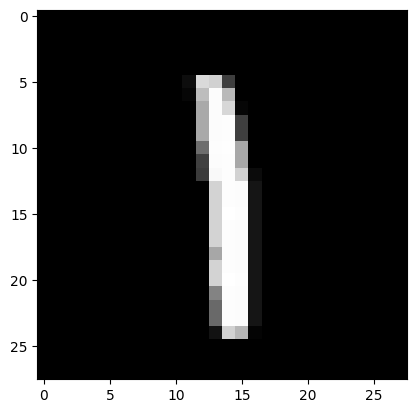

In [14]:
plot(data,model)